<div align="center">

# 📊 Phân tích dữ liệu khám phá (Exploratory Data Analysis)

</div>



---

**Data Analyst:** Nguyễn Khắc Hưng  
**Ngày:** 30-3-2026  
**Description:** Phân Tích Dữ liệu Khám Phá



---


### Import thư viện 📦

In [ ]:

# import các thư viện cần thiết 

# import các thư viện xử lý dữ liệu và trực quan hóa dữ liệu
from pandas.plotting import lag_plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, Normalizer

# import các thư viện dùng để sử dụng các thuật toán kiểm dịnh thống kê
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf, ccf, grangercausalitytests
from scipy.stats import spearmanr
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# import thư viện xóa cảnh báo
import warnings
warnings.filterwarnings("ignore")


### Định nghĩa hàm sử dụng ⚙️

In [ ]:

# Định nghĩa hàm để lấy ra các giá trị outlier của các cột
def lay_ra_cac_outlier(df,ten_cot,lower_bound_cot,upper_bound_cot):
    return df[(df[ten_cot] < lower_bound_cot) | (df[ten_cot] > upper_bound_cot)]

# Định nghĩa hàm để chọn lag
def lag_order_selection(acf_pacf_list,threshold):
    for i in range(len(acf_pacf_list)):
        if(acf_pacf_list[i] < threshold):
            print(i-1)

# Định nghĩa hàm để chạy kiểm định thống kê GC test
def GC_test(df,feature, target):
    feature_ = df[feature].dropna()
    target_ = df[target].dropna()
    min_len = min(len(feature_),len(target_))
    feature_ = feature_[-min_len:]
    target_ = target_[-min_len:]
    df2 = pd.DataFrame(list(zip(target_,feature_)), columns=[target,feature])
    results = grangercausalitytests(
        df2[[target,feature]],
        maxlag=10,
        verbose=False
    );
    p_values = []
    for lag in range(1, 11):
        p_value = results[lag][0]['ssr_ftest'][1]
        p_values.append(p_value)
    print(f'Lag {p_values.index(min(p_values))+1} p-value: {min(p_values)}')
    return min(p_values),p_values.index(min(p_values))



In [4]:

# Load dữ liệu từ file .csv
df = pd.read_csv(r"C:\học Python\Data Science and Atifficial Interligent\Các project data science và AI\Data Analsys\Phân tích dữ liệu và xây dựng hybrid model trong việc dự đoán volatility của Bitcoin tại thi trường crypto toàn cầu\data\Bitcoin_time_series_raw.csv")
df.drop(columns='Unnamed: 0',inplace=True)
df


,timestamp,open,high,low,close,volume,ATR,BB_width_norm,RSI,MACD_Hist,MA20,EMA20,Date,CFGI,BTC Dominance,Total CMC,USDTD,Bitcoin CMC,volatility_14_annual
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,315.640000,NaN,NaN,0.000000,NaN,13529.010000,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
1,2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,316.381068,NaN,0.000000,-1.201493,NaN,13527.654699,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
2,2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,315.799756,NaN,-0.116553,-1.911172,NaN,13526.833598,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
3,2018-01-01 03:00:00,13330.26,13611.27,13290.00,13410.03,420.087030,315.832221,NaN,-0.190124,-2.312652,NaN,13526.347928,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
4,2018-01-01 04:00:00,13434.98,13623.29,13322.15,13601.01,340.807329,315.745026,NaN,-0.367052,-2.002172,NaN,13526.658373,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71661,2026-03-10 23:00:00,69721.58,69981.80,69698.46,69948.63,1165.159140,630.619773,0.125565,22715.462812,798.079696,67678.468042,68793.166000,2026-03-10,13.0,59.352780,2.357494e+12,7.801736,1.399238e+12,0.613922
71662,2026-03-11 00:00:00,69948.64,70173.25,69759.63,70044.87,728.929610,629.331941,0.125669,15875.054066,799.139303,67685.964667,68798.370590,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.613833
71663,2026-03-11 01:00:00,70044.87,70144.00,69880.00,70071.26,947.248790,627.163799,0.125801,14663.557223,800.221240,67692.641000,68803.663270,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.599838
71664,2026-03-11 02:00:00,70071.26,70119.59,69614.00,69810.72,1612.875480,626.442292,0.125898,61217.518220,800.267129,67698.840000,68807.850616,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.600167


### Khám phá dữ liệu 🔍

In [5]:
df.head()

,timestamp,open,high,low,close,volume,ATR,BB_width_norm,RSI,MACD_Hist,MA20,EMA20,Date,CFGI,BTC Dominance,Total CMC,USDTD,Bitcoin CMC,volatility_14_annual
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,315.640000,NaN,NaN,0.000000,NaN,13529.010000,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
1,2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,316.381068,NaN,0.000000,-1.201493,NaN,13527.654699,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
2,2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,315.799756,NaN,-0.116553,-1.911172,NaN,13526.833598,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
3,2018-01-01 03:00:00,13330.26,13611.27,13290.00,13410.03,420.087030,315.832221,NaN,-0.190124,-2.312652,NaN,13526.347928,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN
4,2018-01-01 04:00:00,13434.98,13623.29,13322.15,13601.01,340.807329,315.745026,NaN,-0.367052,-2.002172,NaN,13526.658373,2018-01-01,NaN,41.779461,5.354920e+11,0.257424,2.237257e+11,NaN


In [6]:
df.tail()

,timestamp,open,high,low,close,volume,ATR,BB_width_norm,RSI,MACD_Hist,MA20,EMA20,Date,CFGI,BTC Dominance,Total CMC,USDTD,Bitcoin CMC,volatility_14_annual
71661,2026-03-10 23:00:00,69721.58,69981.80,69698.46,69948.63,1165.15914,630.619773,0.125565,22715.462812,798.079696,67678.468042,68793.166000,2026-03-10,13.0,59.352780,2.357494e+12,7.801736,1.399238e+12,0.613922
71662,2026-03-11 00:00:00,69948.64,70173.25,69759.63,70044.87,728.92961,629.331941,0.125669,15875.054066,799.139303,67685.964667,68798.370590,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.613833
71663,2026-03-11 01:00:00,70044.87,70144.00,69880.00,70071.26,947.24879,627.163799,0.125801,14663.557223,800.221240,67692.641000,68803.663270,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.599838
71664,2026-03-11 02:00:00,70071.26,70119.59,69614.00,69810.72,1612.87548,626.442292,0.125898,61217.518220,800.267129,67698.840000,68807.850616,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.600167
71665,2026-03-11 03:00:00,69810.73,69887.11,69669.88,69735.51,217.64729,624.013733,0.125992,757700.798537,799.979867,67704.578750,68811.707827,2026-03-11,15.0,59.333411,2.350619e+12,7.823834,1.394702e+12,0.598911


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71666 entries, 0 to 71665
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             71666 non-null  object 
 1   open                  71666 non-null  float64
 2   high                  71666 non-null  float64
 3   low                   71666 non-null  float64
 4   close                 71666 non-null  float64
 5   volume                71666 non-null  float64
 6   ATR                   71666 non-null  float64
 7   BB_width_norm         71187 non-null  float64
 8   RSI                   71665 non-null  float64
 9   MACD_Hist             71666 non-null  float64
 10  MA20                  71187 non-null  float64
 11  EMA20                 71666 non-null  float64
 12  Date                  71666 non-null  object 
 13  CFGI                  70827 non-null  float64
 14  BTC Dominance         71666 non-null  float64
 15  Total CMC          

---
##### Khám phá dữ liệu🧐
- *Bộ dữ liệu này tên là Bitcoin_time_series_raw.csv* 
- *Bộ dữ liệu nói về giá, độ biến động của đồng tiền điện tử Bitcoin và các yếu tố ảnh hưởng đến nó trên thị trường crypto*
- *Bộ dữ liệu được thu thập bằng các thư viện và API chính thức của các trang giao dịch crypto uy tín, chính thống: dữ liệu giá (OHLCV) (timestamp/open/high/low/close/volumne) được thu thập từ API chính thức của Binance thông qua thư viện ccxt, dữ liệu chỉ số kỹ thuật (ATR/BB_width_norm/RSI/MACD_Hist/MA20/EMA20) được tính thông qua dữ liệu giá, dữ liệu thị trường được thu thập từ API của nhiều nguồn, CFGI được thu thập từ API của trang Alternative.com, BTC Dominance/Total CMC/USDTD/Bitcoin CMC được thu thập từ API của trang trading view thông qua thư viện Tvdatafeed()*
- *Bộ dữ liệu có 19 feature và 71600 sample, trong đó có 2 feature là kiểu dữ liệu object (timestamp/Date), có 17 cột kiểu dữ liệu float64 (open/high/low/close/volumne/ATR/BB_width_norm/RSI/MACD_Hist/MA20/EMA20/CFGI/BTC Dominance/Total CMC/USDTD/Bitcoin CMC)*
---

In [8]:
describe = df.describe()
describe.loc['CV'] = describe.loc['std']/describe.loc['mean']
describe

,open,high,low,close,volume,ATR,BB_width_norm,RSI,MACD_Hist,MA20,EMA20,CFGI,BTC Dominance,Total CMC,USDTD,Bitcoin CMC,volatility_14_annual
count,71666.000000,71666.000000,71666.000000,71666.000000,71666.000000,71666.000000,71187.000000,7.166500e+04,71666.000000,71187.000000,71666.000000,70827.000000,71666.000000,7.166600e+04,71666.000000,7.166600e+04,71330.000000
mean,38237.649630,38391.358611,38076.186277,38238.430792,2681.799490,314.455241,0.212261,-5.127925e+02,-2.518684,38217.446529,38053.682011,46.529854,54.284418,1.370063e+12,4.095351,7.422421e+11,0.604835
std,32490.751924,32590.035339,32387.871267,32490.837238,3942.050725,250.330875,0.135966,4.566234e+05,472.019068,32436.911219,32337.970742,21.921316,8.976478,1.099125e+12,2.223086,6.499585e+11,0.307119
min,3172.620000,3184.750000,3156.260000,3172.050000,0.000000,16.064423,0.027405,-6.630696e+07,-2340.912320,3492.338667,3494.580364,5.000000,36.619726,9.337764e+10,0.198771,5.548228e+10,0.154784
25%,9555.727500,9594.877500,9506.987500,9555.802500,822.472025,89.955480,0.113927,-1.356723e+03,-174.893791,9471.191552,9477.146614,27.000000,45.730352,2.833310e+11,2.073149,1.725745e+11,0.408982
50%,28114.630000,28237.050000,28007.160000,28118.300000,1461.633305,231.192138,0.173634,2.864089e+02,5.883394,28174.954646,27770.049796,46.000000,55.297968,1.101079e+12,4.196392,5.449204e+11,0.544404
75%,59370.250000,59623.970000,59134.482500,59371.657500,2818.719493,509.445506,0.275934,1.119395e+03,175.480618,59468.886302,59435.152296,65.000000,60.876429,2.203849e+12,5.801133,1.148321e+12,0.699917
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,1167.657275,0.882873,7.271987e+07,2024.283429,118259.934083,118438.002756,95.000000,72.792584,4.219046e+12,9.278930,2.485491e+12,2.587513
CV,0.849706,0.848890,0.850607,0.849691,1.469927,0.796078,0.640561,-8.904643e+02,-187.407040,0.848746,0.849799,0.471124,0.165360,8.022437e-01,0.542832,8.756692e-01,0.507774


---
##### Khám phá dữ liệu🧐
**Nhóm dữ liệu giá Bitcoin**
- *open: Là giá mở của của Bitcoin trong một phiên giao dịch tại thị trường tiền điện tử crypto, tính theo đơn vị tiền tệ USD*
- *high: Là giá cao nhất của Bitcoin trong một phiên giao dịch tại thị trường tiền điện tử crypto, tính theo đơn vị tiền tệ USD*
- *low: Là giá thấp nhất của Bitcoin trong một phiên giao dịch tại thị trường tiền điện tử crypto, tính theo đơn vị tiền tệ USD*
- *close: Là giá đóng cửa (giá kết thúc phiên giao dịch) của Bitcoin trong một phiên giao dịch tại thị trường tiền điện tử crypto, tính theo đơn vị tiền tệ USD*
- *volume: Tổng số lượng Bitcoin được giao dịch trong một phiên giao dịch tại thị trường tiền điện tử crypto, tính theo đơn vị BTC*

**Nhóm chỉ báo kỹ thuật (Technical Indicators)**
- *ATR: Là chỉ báo Average True Range, dùng để đo lường mức độ biến động (volatility) của giá Bitcoin trong một khoảng thời gian nhất định. ATR không cho biết xu hướng tăng hay giảm mà chỉ phản ánh mức độ dao động của giá. Giá trị ATR càng lớn cho thấy thị trường biến động mạnh, còn ATR nhỏ cho thấy thị trường đang ổn định hơn.*
- *BB_width_norm: Là độ rộng của Bollinger Bands đã được chuẩn hóa (normalized). Chỉ số này phản ánh mức độ biến động của giá bằng cách đo khoảng cách giữa dải trên (upper band) và dải dưới (lower band) của Bollinger Bands so với đường trung bình. Giá trị càng lớn cho thấy thị trường biến động mạnh, trong khi giá trị nhỏ cho thấy thị trường đang đi ngang (sideway) hoặc biến động thấp.*
- *RSI: Là chỉ báo Relative Strength Index, dùng để đo lường mức độ quá mua (overbought) hoặc quá bán (oversold) của Bitcoin dựa trên động lượng thay đổi của giá. RSI có giá trị từ 0 đến 100, trong đó RSI > 70 thường cho thấy thị trường đang ở trạng thái quá mua, còn RSI < 30 cho thấy thị trường đang ở trạng thái quá bán.*
- *MACD_Hist: Là phần Histogram của chỉ báo MACD (Moving Average Convergence Divergence). MACD Histogram biểu diễn sự chênh lệch giữa đường MACD và đường tín hiệu (signal line), giúp đánh giá sức mạnh của xu hướng giá. Giá trị dương cho thấy xu hướng tăng đang mạnh lên, trong khi giá trị âm cho thấy xu hướng giảm đang chiếm ưu thế.*
- *MA20: Là đường trung bình động đơn giản (Simple Moving Average) của giá đóng cửa Bitcoin trong 20 phiên giao dịch gần nhất. Chỉ báo này giúp làm mượt dữ liệu giá và hỗ trợ xác định xu hướng ngắn hạn của thị trường.*
- *EMA20: Là đường trung bình động lũy thừa (Exponential Moving Average) của giá đóng cửa Bitcoin trong 20 phiên giao dịch gần nhất. Khác với MA20, EMA20 đặt trọng số lớn hơn cho các mức giá gần thời điểm hiện tại, do đó phản ứng nhanh hơn với các thay đổi của xu hướng giá.*

**Nhóm chỉ số thị trường và tâm lý (Market & Sentiment Indicators)**
- *CFGI: Là chỉ số Crypto Fear and Greed Index, dùng để đo lường mức độ tâm lý sợ hãi (fear) hoặc tham lam (greed) của nhà đầu tư trên thị trường tiền điện tử. Chỉ số này tổng hợp nhiều yếu tố như biến động giá, khối lượng giao dịch, xu hướng tìm kiếm và hoạt động trên mạng xã hội. Giá trị CFGI thấp cho thấy thị trường đang trong trạng thái sợ hãi, còn giá trị cao cho thấy tâm lý tham lam đang chiếm ưu thế.*
- *BTC Dominance: Là tỷ lệ phần trăm vốn hóa thị trường của Bitcoin so với tổng vốn hóa của toàn bộ thị trường tiền điện tử. Chỉ số này phản ánh mức độ ảnh hưởng và sức mạnh của Bitcoin trên thị trường crypto. BTC Dominance tăng cho thấy dòng tiền đang tập trung nhiều vào Bitcoin, trong khi giảm cho thấy dòng tiền đang dịch chuyển sang các altcoin.*
- *Total CMC: Là tổng vốn hóa thị trường của toàn bộ các loại tiền điện tử được thống kê trên CoinMarketCap. Chỉ số này phản ánh quy mô tổng thể của thị trường crypto và thường được sử dụng để đánh giá xu hướng tăng trưởng hoặc suy giảm của toàn thị trường.*
- *USDTD: Là chỉ số dominance của USDT (Tether), thể hiện tỷ lệ vốn hóa của đồng stablecoin USDT so với tổng vốn hóa của thị trường tiền điện tử. Khi USDTD tăng, điều đó cho thấy nhà đầu tư có xu hướng chuyển tài sản sang stablecoin để giảm rủi ro; khi USDTD giảm, dòng tiền có xu hướng quay lại các tài sản rủi ro như Bitcoin hoặc altcoin.*
- *Bitcoin CMC: Là vốn hóa thị trường (market capitalization) của Bitcoin, được tính bằng cách lấy giá Bitcoin nhân với tổng số lượng Bitcoin đang lưu hành trên thị trường. Chỉ số này phản ánh quy mô và giá trị thị trường của Bitcoin trong hệ sinh thái tiền điện tử.*
- *volatility_20_annual: Là độ biến động giá Bitcoin được tính dựa trên độ lệch chuẩn của lợi suất (returns) trong 20 phiên giao dịch gần nhất và được quy đổi theo năm (annualized volatility). Chỉ số này phản ánh mức độ rủi ro và biến động của giá Bitcoin trong ngắn hạn; giá trị càng cao cho thấy thị trường càng biến động mạnh.*
---

In [9]:
df.describe(include='O')

,timestamp,Date
count,71666,71666
unique,71666,2992
top,2026-03-11 03:00:00,2026-02-23
freq,1,24


---
##### Khám phá dữ liệu🧐
- *timestamp: Là tần suất lấy dữ liệu, timestamp được lấy theo h và lấy từ 0h ngày 1-1-2018 đến hiện tại (9h ngày 8/3/2026)*
- *Date: Là dữ liệu tần suất theo ngày được tạo ra để có thể kết hợp với dữ liệu thị trường vì dữ liệu thị trường như BTC dominance chỉ có theo ngày (có thể xóa nếu không cần thiết)*

---

In [10]:
null_columns = df.columns[df.isnull().any()].to_list()
null_columns

['BB_width_norm', 'RSI', 'MA20', 'CFGI', 'volatility_14_annual']

In [11]:
df_totla_null = df.isnull().sum().reset_index()
df_totla_null.rename(columns={0:'total null'},inplace=True)
df_totla_null

,index,total null
0,timestamp,0
1,open,0
2,high,0
3,low,0
4,close,0
5,volume,0
6,ATR,0
7,BB_width_norm,479
8,RSI,1
9,MACD_Hist,0


---
##### Khám phá dữ liệu🧐
- *Dữ liệu có 5 cột bị missing values là BB_width_norm, RSI, MA20, CFGI, volatility_20_annual*
- *trong đó BB_width_norm missing 19 dữ liệu, RSI missing 1 dữ liệu, MA20 missing 19 dữ liệu, CFGI missing 893 dữ liệu và volatility_20_annual missing 20 dữ liệu*
- *Các loại missing này hầu hết không phải missing do quá trình nhập sai, nhập thiếu, .. mà suất phát từ việc tính toán dữ liệu sinh ra*
- *BB_width_norm, MA20, volatility_20_annual bị missing 19 dữ liệu do trong công thức tính toán có sử dụng rolling(20), RSI bị missing 1 giá trị đầu vì trong công thức có sử dụng [close].shift() và CFGI bị mất 893 dữ liệu vì dữ liệu CFGI chỉ có từ ngày 1/2/2018 trong khi dữ liệu giá có từ ngày 1/1/2018 vì vậy cách xử lý chuẩn nhất là nên xóa, CFGI thiếu nhiều nhất nhưng so với tổng dữ liệu cũng chỉ chiếm 1,2% nên ko ảnh hưởng đến toàn bộ dữ liệu khi xóa*
---

In [12]:
total_duplicate = df.duplicated().sum()
total_duplicate

np.int64(0)

In [13]:
Numerical_columns = df.select_dtypes(include=['float64']).columns.to_list()
Q1 = df[Numerical_columns].quantile(0.25)
Q1
Q3 = df[Numerical_columns].quantile(0.75)
Q3
IQR = Q3-Q1
IQR

open                    4.981452e+04
high                    5.002909e+04
low                     4.962749e+04
close                   4.981585e+04
volume                  1.996247e+03
ATR                     4.194900e+02
BB_width_norm           1.620071e-01
RSI                     2.476117e+03
MACD_Hist               3.503744e+02
MA20                    4.999769e+04
EMA20                   4.995801e+04
CFGI                    3.800000e+01
BTC Dominance           1.514608e+01
Total CMC               1.920518e+12
USDTD                   3.727984e+00
Bitcoin CMC             9.757461e+11
volatility_14_annual    2.909349e-01
dtype: float64

In [14]:
lower_bound = Q1 - 1.5*IQR
lower_bound = lower_bound.reset_index()
lower_bound.rename(columns={0 : 'lower_bound'},inplace=True)
lower_bound

,index,lower_bound
0,open,-6.516606e+04
1,high,-6.544876e+04
2,low,-6.493425e+04
3,close,-6.516798e+04
4,volume,-2.171899e+03
5,ATR,-5.392796e+02
6,BB_width_norm,-1.290836e-01
7,RSI,-5.070899e+03
8,MACD_Hist,-7.004554e+02
9,MA20,-6.552535e+04


In [15]:
upper_bound = Q3 + 1.5*IQR
upper_bound = upper_bound.reset_index()
upper_bound.rename(columns={0 : 'upper_bound'},inplace=True)
upper_bound

,index,upper_bound
0,open,1.340920e+05
1,high,1.346676e+05
2,low,1.335757e+05
3,close,1.340954e+05
4,volume,5.813091e+03
5,ATR,1.138681e+03
6,BB_width_norm,5.189448e-01
7,RSI,4.833571e+03
8,MACD_Hist,7.010422e+02
9,MA20,1.344654e+05


In [16]:
Outliers = []
for i in range(len(upper_bound)):
    outlier = lay_ra_cac_outlier(df,upper_bound['index'][i],lower_bound['lower_bound'][i],upper_bound['upper_bound'][i])
    if(outlier is None):
        Outliers.append(outlier)
Outliers


[]

In [17]:
df['timestamp'].dtype

dtype('O')

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

### Phân tích dữ liệu 📊

##### Decomposition Analysis

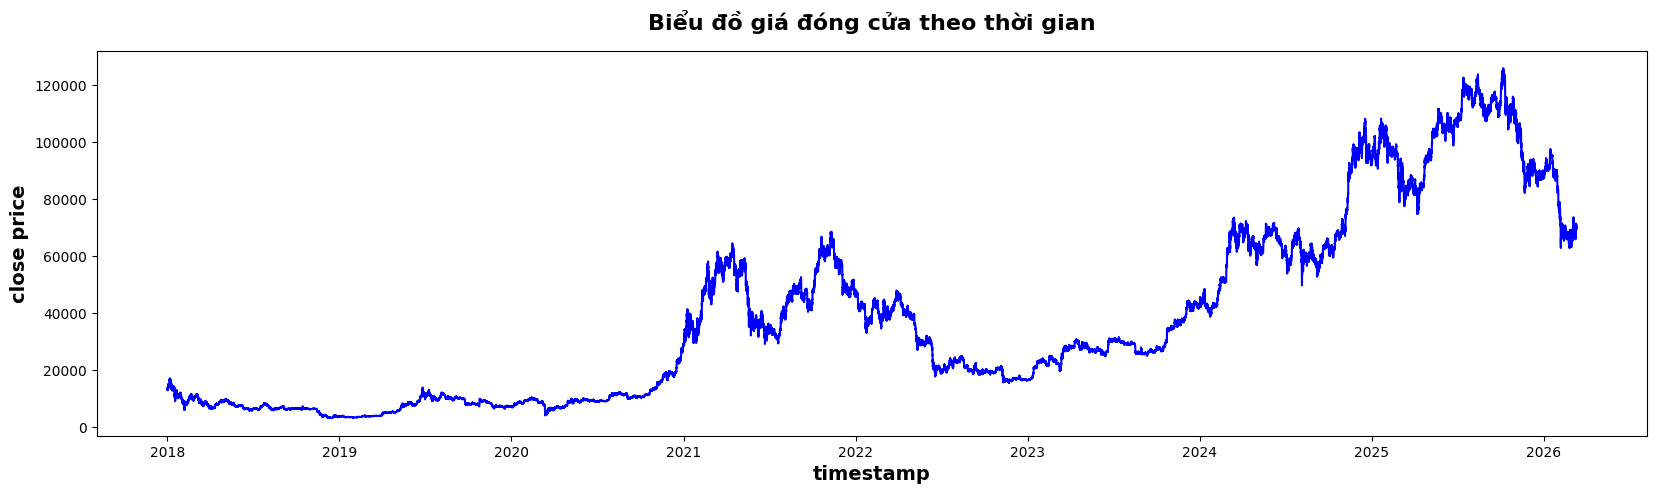

In [19]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],df['close'],color='blue');
plt.title("Biểu đồ giá đóng cửa theo thời gian",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("close price",fontsize=14,fontweight='bold');


---
##### Phân Tích dữ liệu🧐
- *Quan sát biểu đồ giá đóng cửa theo thời gian cho thấy giá của Bitcoin có xu hướng tăng trong dài hạn, thể hiện qua việc các đỉnh và đáy phía sau cao hơn đỉnh và đáy phía trước, tuy nhiên vẫn có những giai đoạn điều chỉnh, giá của Bitcoin vẫn giảm như năm 2020,2023, cho thấy mức độ biến động cao đặc chưng của thị trường crypto*
- *Quan sát biểu đồ giá đóng cửa theo thời gian ta thấy, giai đoạn từ 2018-2019 giá giao động +-1k-2k, giai đoạn từ 2021-2022 giá giao động +-10k-20k, giai doạn từ 2024-2026 giá giao động +-20k-40k, điều này nghĩa là biên độ dao động tăng theo mức giá, giá bitcoin càng cao thì giao động càng lớn và ngược lại, điều này thể hiện giá ko co xu hướng constant (chỉ giao động trong 1 khoảng +-xk)*
- *Từ phân tích bên trên ta rút ra kết luận nên phân rã dữ liệu bằng Mutiplicative model thay vì Addtive model như thông thường*
---

In [20]:

result = seasonal_decompose(
    df['close'],
    model='multiplicative',
    period=168
)


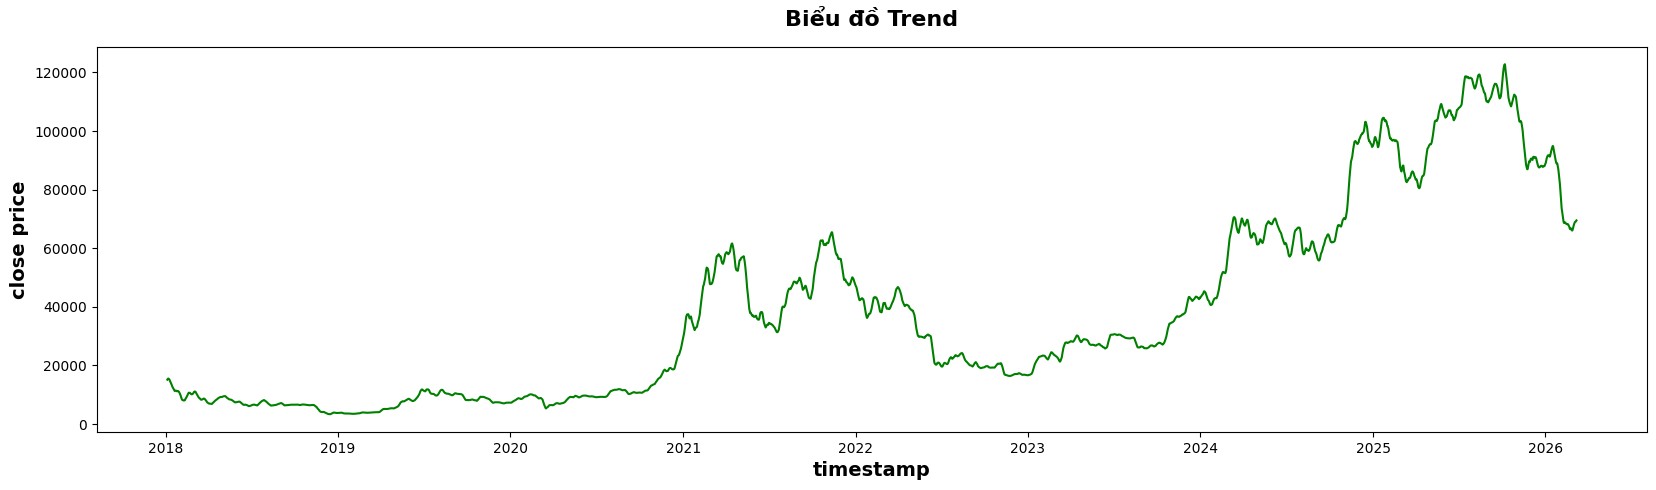

In [21]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],result.trend,color='green');
plt.title("Biểu đồ Trend",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("close price",fontsize=14,fontweight='bold');

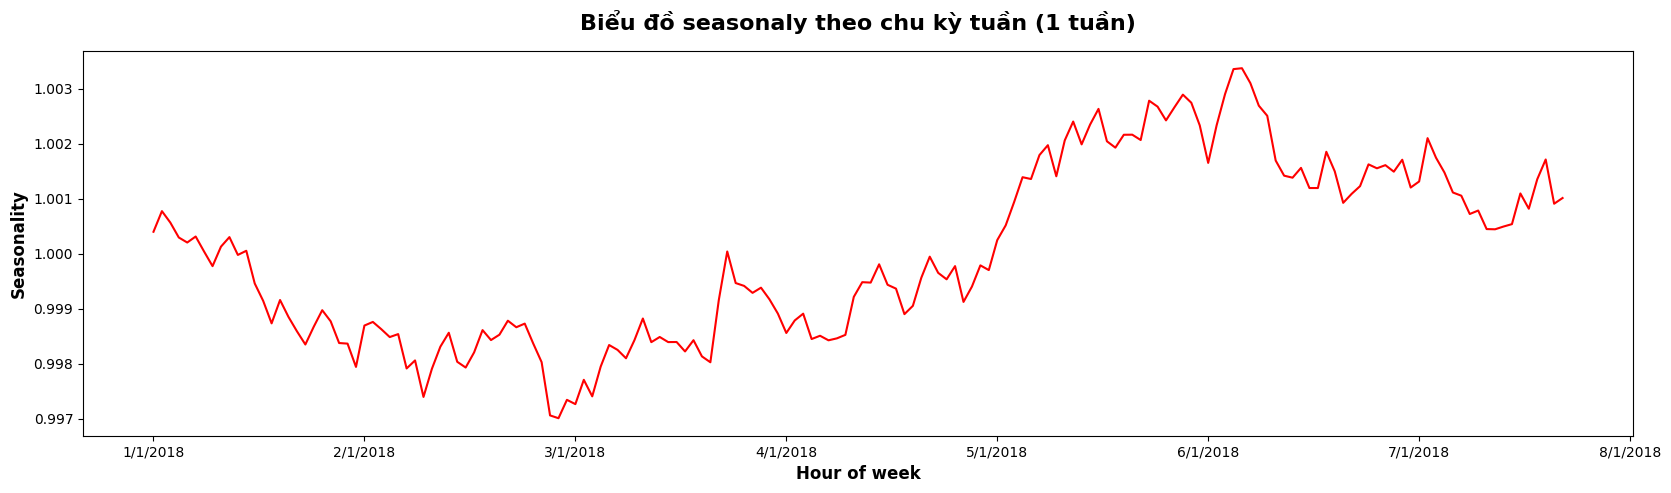

In [22]:
date_seasonal = ["1/1/2018","2/1/2018","3/1/2018","4/1/2018","5/1/2018","6/1/2018","7/1/2018","8/1/2018"]
index = [0,25,50,75,100,125,150,175]
plt.figure(figsize=(20,5));
plt.plot(result.seasonal[:168],color='red');
plt.title("Biểu đồ seasonaly theo chu kỳ tuần (1 tuần)",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("Hour of week",fontsize=12,fontweight='bold');
plt.ylabel("Seasonality",fontsize=12,fontweight='bold');
plt.xticks(
    ticks=index,   
    labels=date_seasonal              
);



---
##### Phân Tích dữ liệu🧐
- *Thành phần seasonal được phân tích theo chu kì 168 giờ (tương ứng với 1 tuần)*
- *Quan sát biểu đồ seasonaly theo chu kì tuần ta thấy rằng các giao động theo chu kì tuần không quá rõ ràng, các giao động chỉ ở múc +- 0.01-0.03, điều này cho thấy giá Bitcoin không có quy luật lặp lại mạnh theo chu kì tuần, điều này là bình thường với đặc điểm của thị trường crypto hoạt không 24/7*

---

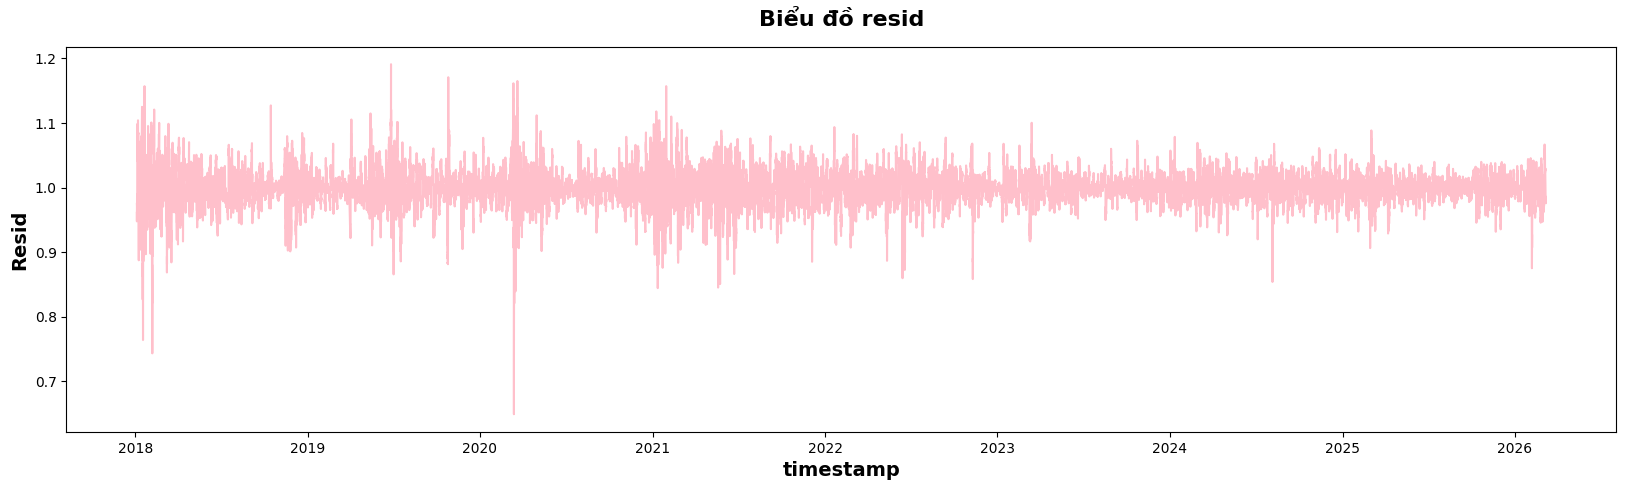

In [23]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],result.resid,color='pink');
plt.title("Biểu đồ resid",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("Resid",fontsize=14,fontweight='bold');

---
##### Phân Tích dữ liệu🧐
- *Resiuual là thành phần còn lại trong cấu trúc của time series khi đã loại bỏ trend là seasonal*
- *Quan sát biểu đồ resid cho thấy residual dao động quanh giá trị trung bình, mức giao động nằm ở mức +-0.1-0.2, xuất hiện một số spike lớn đây có thể là các outlier, tuy nhiên vì đã kiểm tra outlier bên trên và không có outlier nào thì đây là những biến động bất thường hoặc cú sốc thị trường nguyên nhân có thể do chiến tranh, thuế quan, ... đây là điều bình thường của thị trường crypto, chứ không phải spike do nhập sai dữ liệu*

---

##### Stationarity Analysis

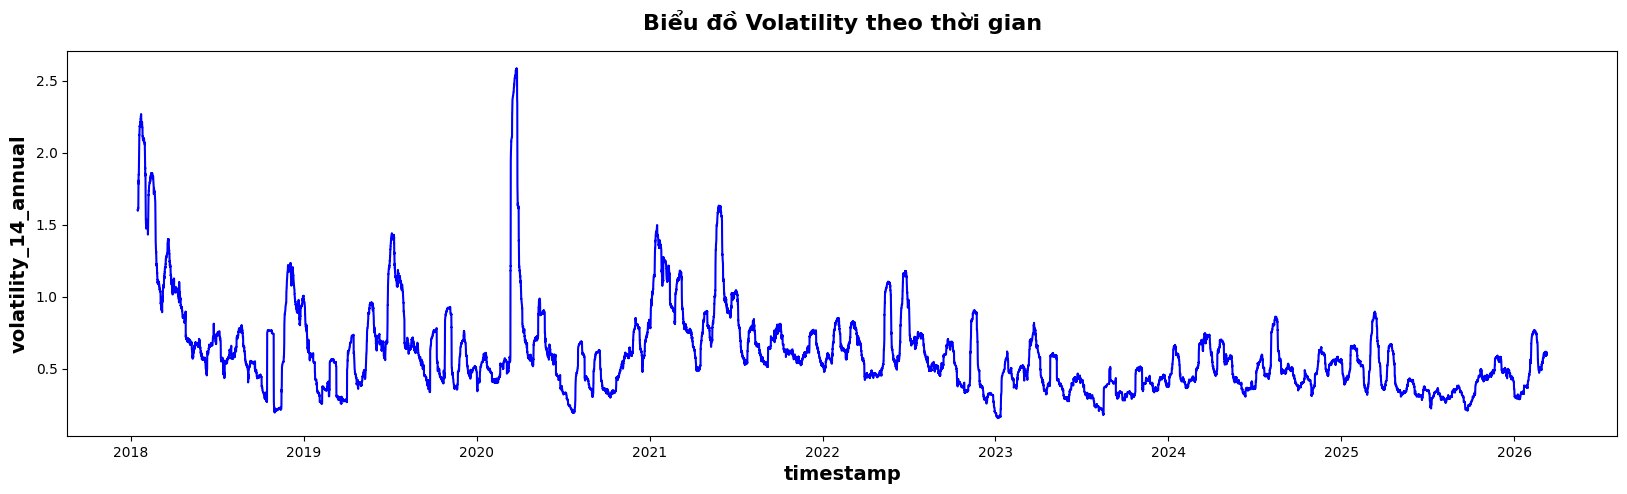

In [24]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],df['volatility_14_annual'],color='blue');
plt.title("Biểu đồ Volatility theo thời gian",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("volatility_14_annual",fontsize=14,fontweight='bold');

---
##### Phân Tích dữ liệu🧐
- *Quan sát biểu đồ Volatility theo thời gian cho thấy dữ liệu đang bị hiện tượng volatility clustering, volatility clustering là hiện tượng giai đoạn volatility cao sẽ tiếp tục cao và giai đoạn volatility thấp sẽ tiếp tục thấp*
- *Lấy năm 2022 làm mốc chia biểu đồ thành 2 phần quan sát ta thấy rằng, từ năm 2018 đến năm 2022 (nửa biểu đồ bên trái) volatility cao và có xu hướng biến động mạnh, còn từ năm 2022 đến năm 2026 (nửa biểu đồ bên trái) volatility thấp và có xu hướng biến động nhẹ*
- *Ta thấy điều này là hoàn toàn bình thường khi xét theo các sự kiện trên thế giới, giai đoạn từ năm 2018 đến năm 2022 là giai đoạn bị ảnh hưởng mạnh bởi covid19, đặc biệt giai đoạn từ năm 2020 đến năm 2021 có volatility cao nhất lên tới 260% điều này là do năm đó các quốc gia đóng cửa, nền kinh tế sụp đổ, mọi hoạt động dừng lại nên dẫn đến thị trường crypto cũng sụp đổ theo. Giai đoạn từ năm 2022 đến năm 2026 là giai đoạn nền kinh tế bắt đầu phục hồi và phát triển lại nên volatility thấp và có phần ổn định hơn*


---

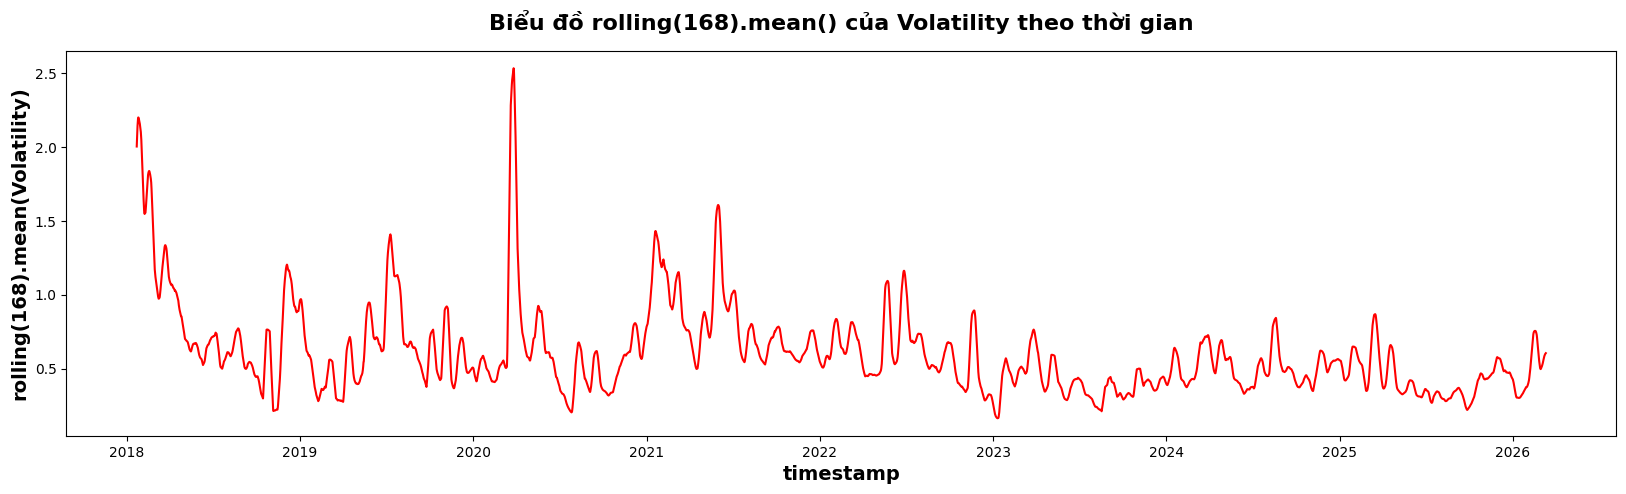

In [25]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],df['volatility_14_annual'].rolling(168).mean(),color='red');
plt.title("Biểu đồ rolling(168).mean() của Volatility theo thời gian",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("rolling(168).mean(Volatility)",fontsize=14,fontweight='bold');

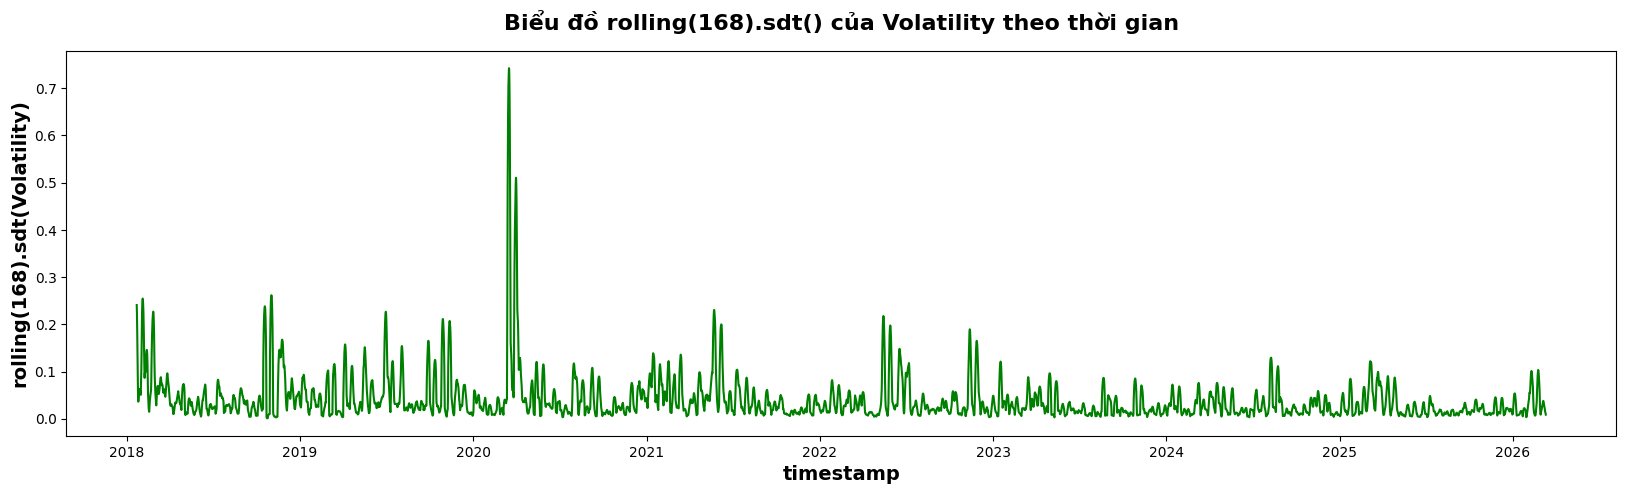

In [26]:
plt.figure(figsize=(20,5))
plt.plot(df['timestamp'],df['volatility_14_annual'].rolling(168).std(),color='green');
plt.title("Biểu đồ rolling(168).sdt() của Volatility theo thời gian",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("timestamp",fontsize=14,fontweight='bold');
plt.ylabel("rolling(168).sdt(Volatility)",fontsize=14,fontweight='bold');

In [27]:
result = adfuller(df['volatility_14_annual'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of lags:", result[2])
print("Number of observations:", result[3])
print("Critical values:", result[4])


ADF Statistic: -7.01168497811397
p-value: 6.895771878876277e-10
Number of lags: 51
Number of observations: 71278
Critical values: {'1%': np.float64(-3.4304417468996893), '5%': np.float64(-2.8615805505122074), '10%': np.float64(-2.5667915836500614)}


---
##### Phân Tích dữ liệu🧐
- *Dựa vào chỉ số thống kê ADF test bên trên ta thấy rằng, p-value = 6.89e-10 < 0.05, ADF statistic = -7.001 < Critical values = -3.43*
- *Từ hai chỉ số thống kê bên trên ta thấy rằng dữ liệu là thuộc dạng stationary ở mức rất tốt, điều này là ổn khi train các model như ARIMA, SARIMA mà không cần xử lý diffirencing. log return hay return*


---

##### correlation Analysis

In [28]:
corr = df[Numerical_columns].corr()
corr

,open,high,low,close,volume,ATR,BB_width_norm,RSI,MACD_Hist,MA20,EMA20,CFGI,BTC Dominance,Total CMC,USDTD,Bitcoin CMC,volatility_14_annual
open,1.000000,0.999978,0.999970,0.999963,-0.199504,0.802674,-0.232498,-0.000228,-0.020608,0.994634,0.995895,0.258432,0.126984,0.984023,0.333168,0.999243,-0.261497
high,0.999978,1.000000,0.999952,0.999979,-0.198159,0.803982,-0.231457,-0.000242,-0.021091,0.994669,0.995923,0.258403,0.126683,0.984121,0.332846,0.999228,-0.260261
low,0.999970,0.999952,1.000000,0.999976,-0.201310,0.801228,-0.233628,-0.000243,-0.020173,0.994550,0.995817,0.258334,0.127320,0.983943,0.333520,0.999288,-0.262814
close,0.999963,0.999979,0.999976,1.000000,-0.199642,0.802653,-0.232455,-0.000244,-0.020608,0.994599,0.995861,0.258479,0.127044,0.984047,0.333119,0.999277,-0.261488
volume,-0.199504,-0.198159,-0.201310,-0.199642,1.000000,-0.111234,0.107921,-0.002335,0.001199,-0.201543,-0.199298,-0.096072,-0.251466,-0.166683,0.257102,-0.199626,0.092153
ATR,0.802674,0.803982,0.801228,0.802653,-0.111234,1.000000,0.092919,0.000078,-0.155736,0.816114,0.811638,0.177074,-0.002146,0.815087,0.183562,0.793136,0.151892
BB_width_norm,-0.232498,-0.231457,-0.233628,-0.232455,0.107921,0.092919,1.000000,-0.001109,0.084050,-0.240679,-0.239736,-0.010159,-0.014283,-0.233912,-0.295740,-0.237939,0.778624
RSI,-0.000228,-0.000242,-0.000243,-0.000244,-0.002335,0.000078,-0.001109,1.000000,0.001858,-0.000395,-0.000379,0.004090,0.003739,-0.001322,-0.000611,-0.000210,-0.001342
MACD_Hist,-0.020608,-0.021091,-0.020173,-0.020608,0.001199,-0.155736,0.084050,0.001858,1.000000,-0.101921,-0.081949,0.191268,0.030586,-0.030659,-0.002117,-0.020794,-0.078049
MA20,0.994634,0.994669,0.994550,0.994599,-0.201543,0.816114,-0.240679,-0.000395,-0.101921,1.000000,0.999765,0.199882,0.106682,0.981205,0.340128,0.994222,-0.248379


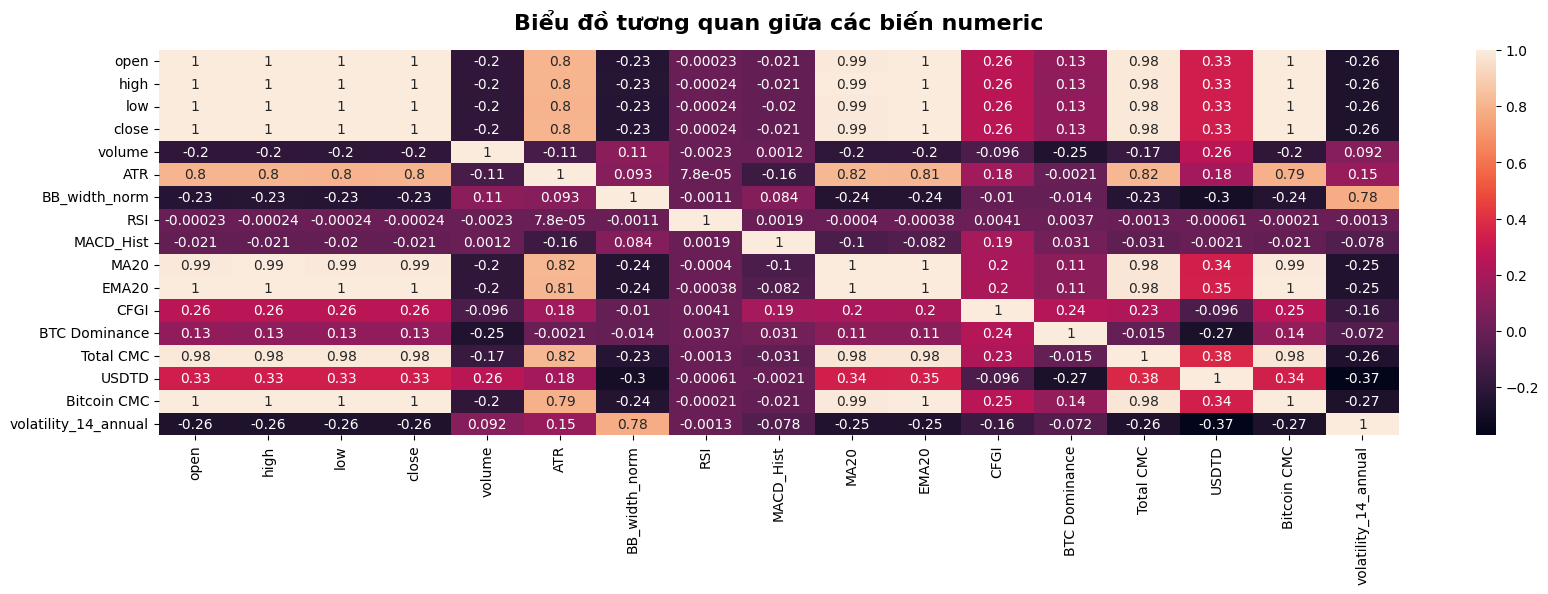

In [29]:
plt.figure(figsize=(20,5))
sns.heatmap(corr,annot=True);
plt.title("Biểu đồ tương quan giữa các biến numeric",fontsize=16,fontweight='bold',pad=15);

##### Lag Analysis

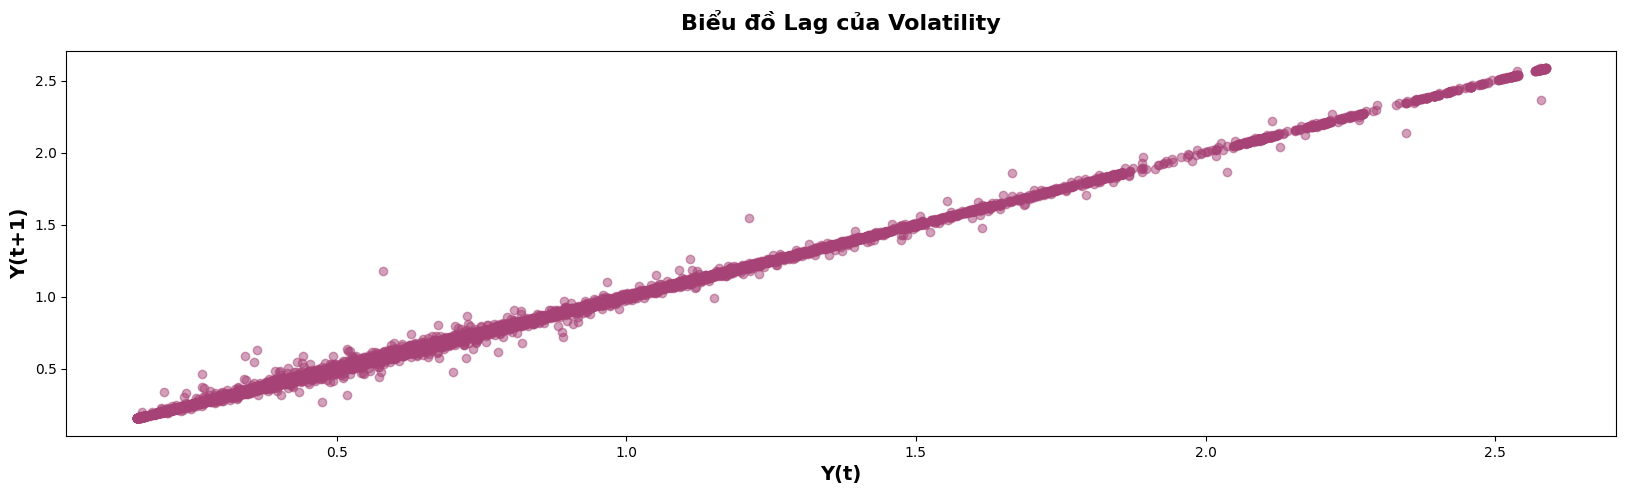

In [30]:
plt.figure(figsize=(20,5));
y_t = df['volatility_14_annual'][:-1]
y_t_1 = df['volatility_14_annual'][1:]
plt.scatter(y_t,y_t_1,color='#A74276',alpha=0.5);
plt.title("Biểu đồ Lag của Volatility",fontsize=16,fontweight='bold',pad=15);
plt.xlabel("Y(t)",fontsize=14,fontweight='bold');
plt.ylabel("Y(t+1)",fontsize=14,fontweight='bold');


---
##### Phân Tích dữ liệu🧐
- *Quan sát biểu đồ Lag của Volatility ta thấy rằng các điểm dữ liệu nằm dọc sát và theo đường chéo ý nghĩa là y(t + 1) sấp sỉ tương đương y(t), điều nãy có nghĩa chuỗi có memory theo thời gian, đây là hiện tượng Autocorrelation*
- *Trong time series tài chính điều này là rất bình thường, với chuỗi dữ liệu như này nên chọn ưu tiên các model như ARIMA, LSTM, Transformer vì các model này tận dụn autocorrelation rất tốt, nhưng có 1 lưu ý volatility được tính bằng rollingstd của return và được tính với 336h (tức 14 ngày) nên việc dữ liệu có auto correlation mạnh có thể do rollingstd tạo ra nên kiểm tra thêm ACF và PACF để kết luận chọn model*



---

In [31]:
threshold = 1.96/(np.sqrt(len(df['volatility_14_annual'].dropna())))
threshold

np.float64(0.007338713938882064)

In [32]:
acf_ = acf(df['volatility_14_annual'].dropna(), nlags=168)
acf_


array([1.        , 0.99971517, 0.99937071, 0.99899323, 0.99858081,
       0.99814506, 0.99768882, 0.99721455, 0.99672337, 0.99621514,
       0.9956916 , 0.99514503, 0.9945832 , 0.99400576, 0.99337791,
       0.99273788, 0.99207217, 0.99137136, 0.99065248, 0.98991621,
       0.989168  , 0.98840481, 0.98763188, 0.98684407, 0.98604174,
       0.98522928, 0.98440666, 0.9835734 , 0.9827313 , 0.9818793 ,
       0.98101999, 0.98015199, 0.9792758 , 0.97838333, 0.97747399,
       0.97655537, 0.9756287 , 0.97469334, 0.97375208, 0.9728043 ,
       0.97185018, 0.97088416, 0.96991357, 0.96893982, 0.96795586,
       0.96696074, 0.9659531 , 0.96494032, 0.96392159, 0.9628947 ,
       0.96186216, 0.96082116, 0.95977221, 0.95871827, 0.95766161,
       0.95660322, 0.95554117, 0.95447285, 0.95339715, 0.95231774,
       0.95123334, 0.95014215, 0.94904004, 0.947934  , 0.94680917,
       0.94567713, 0.94453787, 0.94338565, 0.94222239, 0.94104537,
       0.93985748, 0.93865412, 0.93744204, 0.93622354, 0.93499

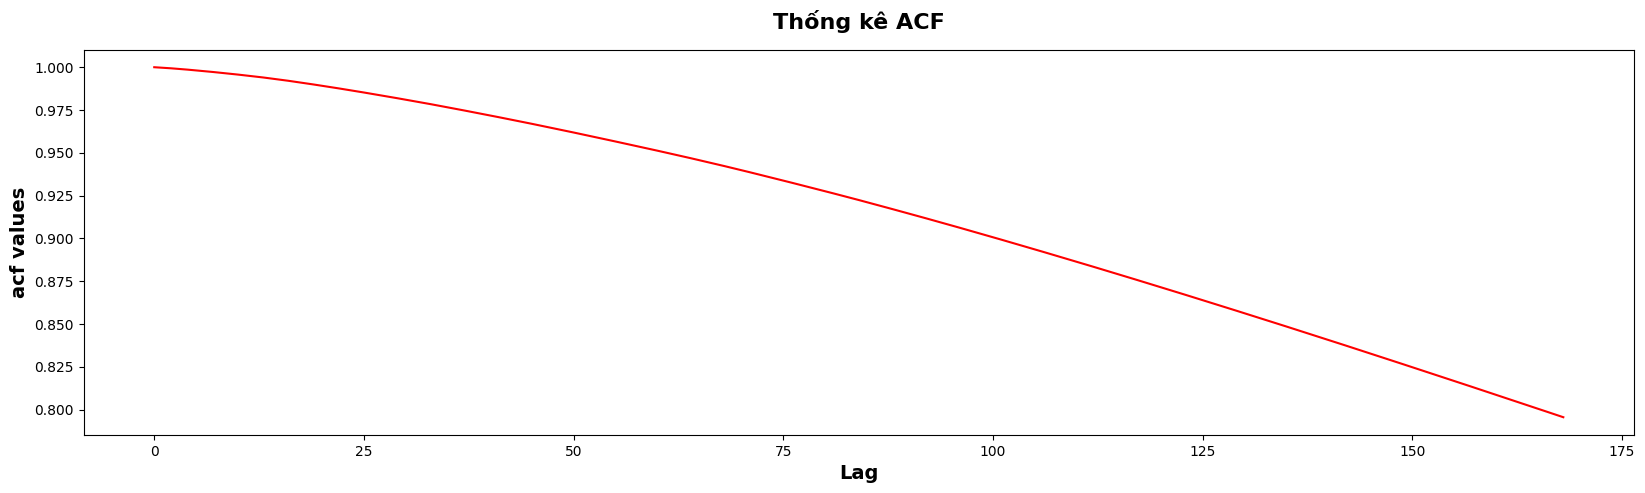

In [33]:
x = np.arange(len(acf_))
plt.figure(figsize=(20,5));
plt.plot(x,acf_,color='red');
plt.title("Thống kê ACF", fontsize=16,fontweight='bold',pad=15);
plt.xlabel("Lag",fontsize=14,fontweight='bold');
plt.ylabel("acf values",fontsize=14,fontweight='bold');



In [34]:
lag_order_selection(acf_,threshold)

In [35]:
pacf_ = pacf(df['volatility_14_annual'].dropna(), nlags=168)
pacf_

array([ 1.00000000e+00,  9.99729190e-01, -1.10275235e-01, -4.96393808e-02,
       -5.36545259e-02, -2.86669956e-02, -2.52473211e-02, -2.08466756e-02,
       -1.96164178e-02, -2.01806586e-02, -1.67173538e-02, -3.16521784e-02,
       -1.40379870e-02, -1.64426353e-02, -8.15912518e-02,  2.77734053e-03,
       -3.22645970e-02, -4.44917953e-02, -1.07513428e-02, -1.27100200e-02,
       -3.01590249e-03, -1.18416102e-02, -1.56213782e-03, -1.42201708e-02,
       -9.73757567e-03, -4.24637113e-03, -4.56274476e-03, -5.70703191e-04,
       -5.18978866e-03, -3.11096011e-03,  3.10849887e-03, -4.93643657e-03,
       -1.94898492e-03, -1.89655270e-02, -1.69141672e-02, -3.58649087e-03,
       -1.20868207e-03, -3.74589810e-03, -2.23293108e-04, -1.45524143e-03,
       -2.29382105e-03, -1.31846891e-02,  2.36136770e-03,  2.44806571e-03,
       -1.06832818e-02, -1.20833097e-02, -1.17424747e-02,  3.40627979e-03,
       -1.89470115e-03, -4.79634426e-03, -2.99205424e-04, -7.50358830e-03,
       -6.21915346e-03, -

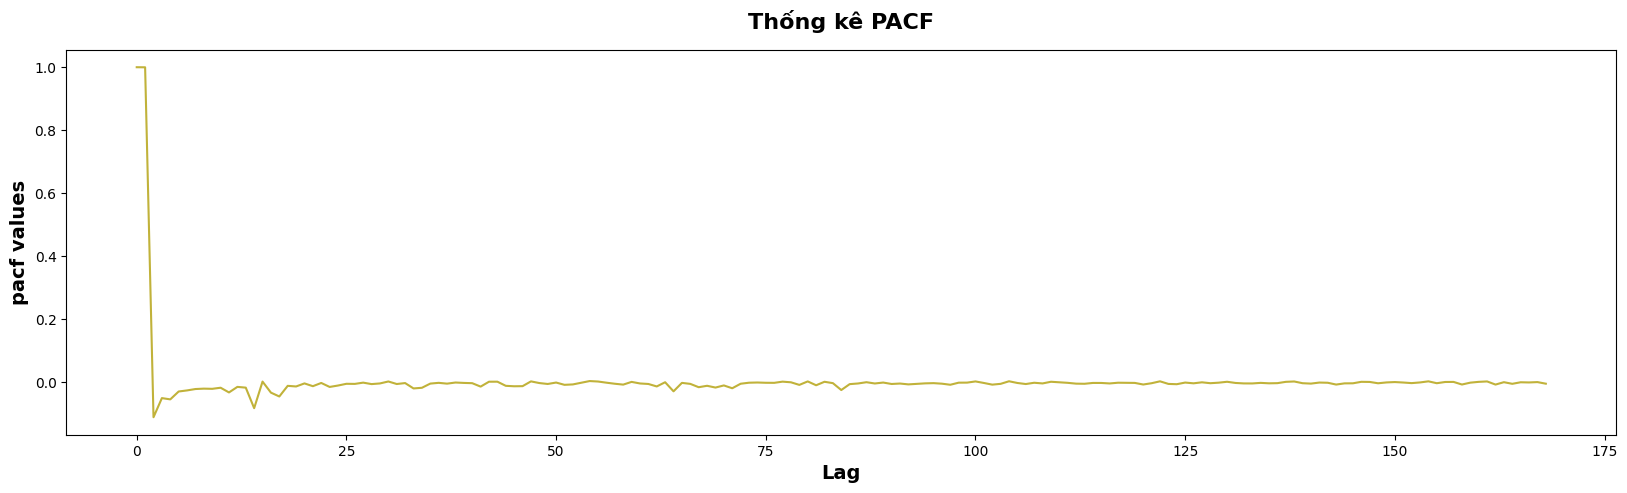

In [36]:
x = np.arange(len(pacf_))
plt.figure(figsize=(20,5))
plt.plot(x,pacf_,color='#C1B23A')
plt.title("Thống kê PACF", fontsize=16,fontweight='bold',pad=15);
plt.xlabel("Lag",fontsize=14,fontweight='bold');
plt.ylabel("pacf values",fontsize=14,fontweight='bold');

In [37]:
lag_order_selection(pacf_,threshold)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167


---
##### Phân Tích dữ liệu🧐
- *Quan sát kết quả chạy hai thuật toán kiểm định thống kê ACF,PACF và biểu đồ giá trị acf, pacf theo lag ta thấy rằng*
- *Giá trị của acf giảm rất chậm, mỗi lag chỉ giảm khoảng 0.01-0.03, đến lag thứ 167 giá trị của acf vẫn nằm ở mức 0.78, so sánh với threshold thì chúng ta không tìm được bậc cho model, điều này cho thấy chuỗi volatility có memory dài hạn, đây là hiện tượng volatility clustering (tăng và giảm theo từng nhóm chu kì)*
- *Điều này cũng giải thích cho việc vì sao giá trị của PACF rất nhỏ, khi chạy hàm lag_order_selection chỉ có giá trị đầu tiên lớn hơn threshold còn hầu hết đều nhỏ hơn threshold, nguyên nhân nằm ở việc khi có memory dài hạn và volatility clustering thì dữ liệu hầu hết sẽ tương quan gián tiếp, mà pacf lại bỏ qua các tương quan gián tiếp nên giá trị pacf rất nhỏ*
- *Từ những phân tích trên ta thấy rằng, hiện tượng auto correlation được biểu diễn là biểu đò lag plot tỷ lệ cao được tạo ra từ công thức tính của volatility bằng rollingstd, với đặc điểm dữ liệu như này của volatility thì các model như ARIMA, SARIMA không hợp lý nó sẽ không học được hết các tính chất đặc điểm của dữ liệu, nên đổi qua các model GARCH*



---

In [38]:
max_lag = 10

for feature in Numerical_columns:

    x = df[feature].dropna()
    y = df['volatility_14_annual'].dropna()

    min_len = min(len(x), len(y))
    x = x[-min_len:]
    y = y[-min_len:]

    ccf_values = ccf(x, y)

    best_lag = np.argmax(np.abs(ccf_values[:max_lag]))
    best_corr = ccf_values[best_lag]

    print(feature, best_lag, best_corr)


open 0 -0.26149723848777917
high 2 -0.2602767184632036
low 0 -0.2628136614238512
close 0 -0.26148767896593506
volume 0 0.09215338974765151
ATR 0 0.15189225746804916
BB_width_norm 0 0.778624017427938
RSI 9 -0.0013566388839482103
MACD_Hist 0 -0.0780486319503902
MA20 9 -0.24890654360705022
EMA20 9 -0.2526902808671835
CFGI 0 -0.16320769378225247
BTC Dominance 9 -0.07192970844922962
Total CMC 0 -0.25847812339535453
USDTD 9 -0.371522211311689
Bitcoin CMC 0 -0.2689854685406286
volatility_14_annual 0 0.9999999999999999


---
##### Phân Tích dữ liệu🧐
- *Quan sát kết quả thuật toán kiểm định thống kê CCF cho thấy, hầu hết |correlation| đều lớn hơn threshold điều này có nghĩa là tất cả các giá trị của correlation đều có nghĩa là sử dụng được, chỉ có |corelation| của RSI là nhỏ hơn threshold (0.0013566 < 0.007) nên giá tị correlation của RSI ko có nghĩa*
- *Trong các correlation thì có 12/17 feature có giá trị correlation âm tức là quan hệ nghịch feature giảm thì target tăng còn feature tăng thì target giảm, có 4/17 correlation dương tức là quan hệ thuận cùng tăng hoặc cùng giảm*
- *Trong kết quả ccf trả về có 4 feature là có bậc lag khác không, còn lại là bậc lag bằng 0*
- *Trong kết quả mà ccf trả về có 1 feature tương quan mạnh với target là BB_width_norm (correlation = 0.77) có 11 feature có tương quan trung bình với target (correlation dao động từ 0.1 đến 0.3) và có 4 feature tương quan thấp với target (correlation dao động từ 0.01 đến 0.09)*
- *Nhưng lưu ý đây chỉ là tương quan giữa các biến feature và target, correlation cao ko đồng nghĩa với việc feature đó giúp dự đoán target tốt khi đưa dữ liệu vào model, cần chạy GC test để thật sự biết biến nào có tác dụng dự đoán lên target*




---

##### Granger causality test

In [39]:
for i in range(len(Numerical_columns)):
    print(Numerical_columns[i])
    if(Numerical_columns[i] == Numerical_columns[-1]):
        continue
    else:
        p_value,index_min_p_value = GC_test(df,Numerical_columns[i],'volatility_14_annual')


open
Lag 6 p-value: 0.052223918685236397
high
Lag 2 p-value: 0.0020982116040672337
low
Lag 4 p-value: 0.2870869603835377
close
Lag 7 p-value: 0.01946622308938077
volume
Lag 1 p-value: 7.811490918786543e-63
ATR
Lag 2 p-value: 1.8878095214419564e-12
BB_width_norm
Lag 2 p-value: 1.0750721753816855e-178
RSI
Lag 1 p-value: 0.9800014254111475
MACD_Hist
Lag 2 p-value: 1.3339805289216692e-23
MA20
Lag 3 p-value: 0.015666169923540835
EMA20
Lag 2 p-value: 8.992226482762624e-11
CFGI
Lag 1 p-value: 0.5966048132822672
BTC Dominance
Lag 1 p-value: 0.3111316435082621
Total CMC
Lag 1 p-value: 0.43767557391546774
USDTD
Lag 3 p-value: 0.20781397411664831
Bitcoin CMC
Lag 1 p-value: 0.47212926004338984
volatility_14_annual


##### Multicollinearity Analysis

In [40]:
independance_feature = df[Numerical_columns].dropna()
independance_feature.drop(columns=['volatility_14_annual'],inplace=True)
VIF = pd.DataFrame()
VIF['feature'] = independance_feature.columns
VIF['vif'] = [variance_inflation_factor(independance_feature.values, i) for i in range(independance_feature.shape[1])]
VIF

,feature,vif
0,open,52249.968491
1,high,72954.934479
2,low,49520.059392
3,close,66257.530444
4,volume,1.439945
5,ATR,6.157654
6,BB_width_norm,1.478119
7,RSI,1.000094
8,MACD_Hist,7.493425
9,MA20,10668.328709


---
##### Phân Tích dữ liệu🧐
- *Quan sát kết quả thuật toán kiểm tra đa cộng tuyến cho thấy rằng đa cộng tuyến cực mạnh xảy ra ở 1 số feature*
- *Nhóm OHLCV, open close high low có đa cộng tuyến rất lớn nên loại bỏ các biến open high low dữ lại close làm biến đại diện*
- *Nhóm chỉ số kỹ thuật MA20 và EMA20 gần như giống nhau, nên xóa MA20 dữ lại EMA20*
- *Nhóm biến thị trường chung, total CMC và bitcoin CMC đa cộng tuyến lớn, dữ lại bitcoin CMC xóa đi total CMC*
- *Nhóm các feature ATR, MACF_Hist, hơi cao nhưng có thể dữ*
- *còn lại là các feature có vif thấp nên dữ liệu để tránh mất thông tin*





---

##### Distribution Analysis

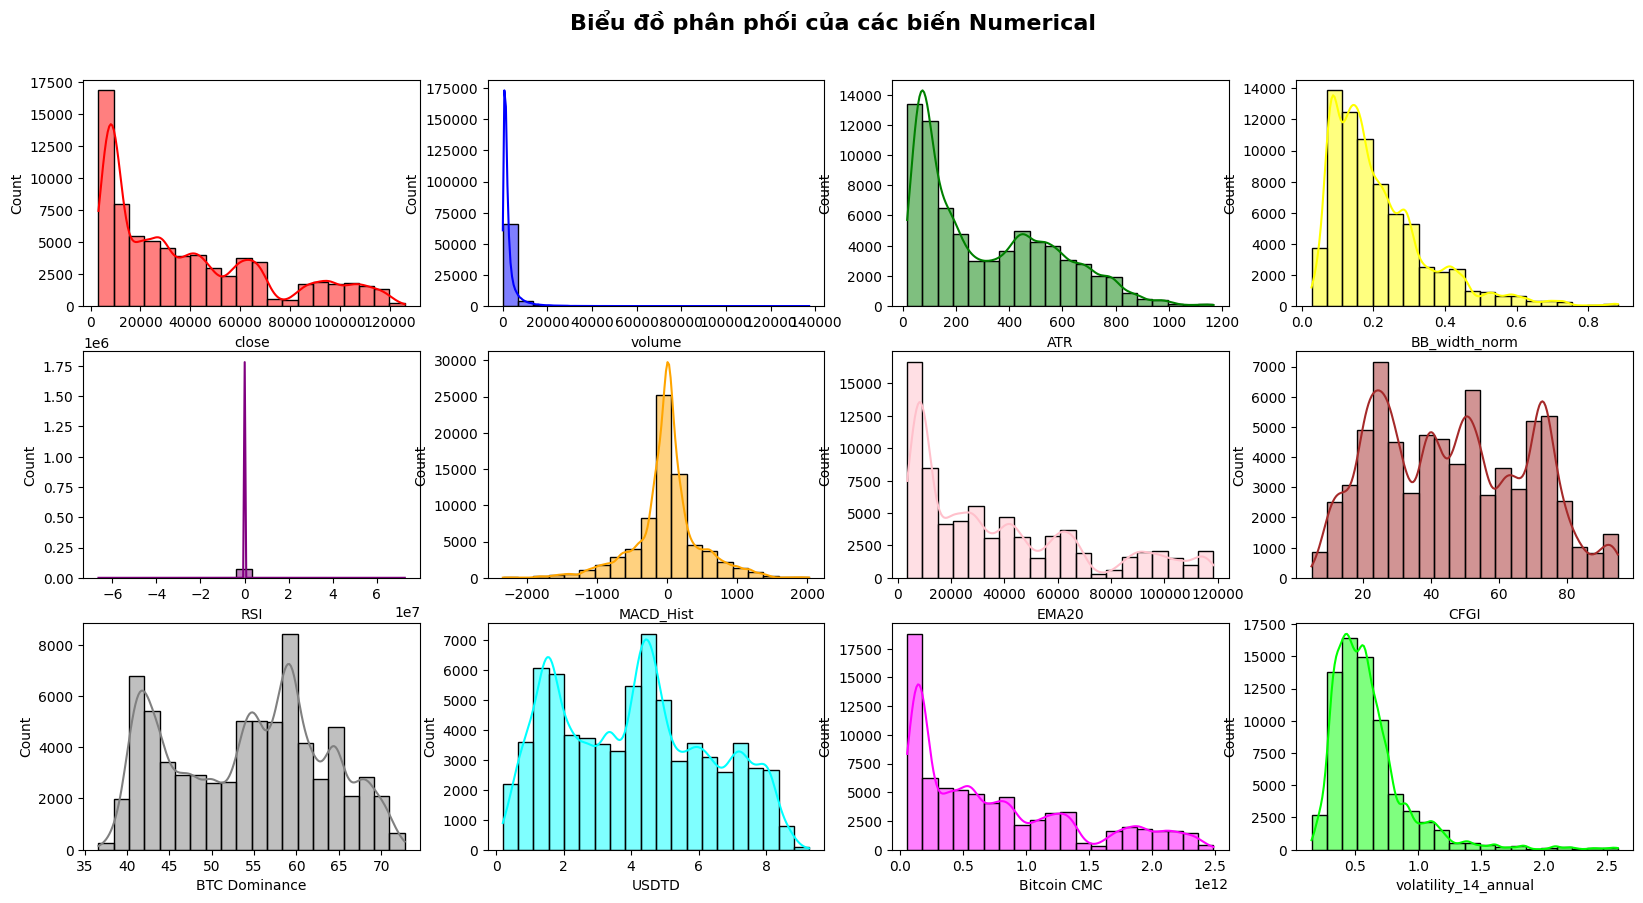

In [47]:
color_list = [
    "red", "blue", "green", "yellow", "purple",
    "orange", "pink", "brown", "gray", "cyan",
    "magenta", "lime", "indigo", "violet", "gold",
    "silver", "navy", "teal", "coral", "maroon"
]
feature_engineering = [
 'close',
 'volume',
 'ATR',
 'BB_width_norm',
 'RSI',
 'MACD_Hist',
 'EMA20',
 'CFGI',
 'BTC Dominance',
 'USDTD',
 'Bitcoin CMC',
 'volatility_14_annual']
fig,ax = plt.subplots(ncols=4,nrows=3,figsize=(20,10))
index=0
for i in range(3):
    for j in range(4):
        try:
            sns.histplot(df[feature_engineering[index]],
                        bins=20,
                        kde=True,
                        ax=ax[i][j],
                        color=color_list[index])
            index+=1
        except:
            break
fig.suptitle("Biểu đồ phân phối của các biến Numerical",y=0.95,fontsize=16,fontweight='bold');

---
##### Phân Tích dữ liệu🧐
- *Quan sát biểu đồ phân phối của các feature cho thấy rằng, có 7 feature lệch phải mạnh đó là close, columne, ATR, EMA20, Bitcoin CMC, volatility, BB_width_morm, phần lớn các giá trị nằm ở phía nhỏ có đuôi dài về phía bên phải, nên xử lý log transform hoặc standard scalling trước khi đưa vào model*
- *Feature MACD_Hist có phân phối gần chuẩn, phân bố tương đối xung quanh 0, điều này là hợp lý vì MACD hist là hiệu giữa MACD và đường tín hiệu*
- *Các feature BTC dominance, DFGI, RSI có phân phối tương đối ổn định và nằm trong giá trị giới hạn, không có các skew quá mạnh, có thể xử lý bằng minmaxscaler cho các feature này*


---